## SDG-Linked Portfolio Project — One-Pager

### Chosen SDG and Sub-Target

**SDG 7 — Affordable and Clean Energy**
**Sub-target 7.1** — "By 2030, ensure universal access to affordable, reliable and modern energy services," measured by indicator **7.1.1: proportion of population with access to electricity**.

**Specific angle:** the persistent **urban–rural electrification gap in Sub-Saharan Africa**. Regional electrification has grown steadily since 2010, but almost all of the remaining "energy access deficit" is concentrated in rural areas, and rural population growth is currently outpacing new rural connections — meaning the absolute number of unconnected rural people is not shrinking even as national percentages improve.

### Why This Excites Me

The headline "% electrified" number that shows up in most SDG dashboards hides a much sharper story once you split it by urban vs. rural. Roughly 82% of urban Sub-Saharan Africans had power in 2023, versus about a third of rural residents — and rural population growth is outrunning new connections, so the raw number of people without power has stayed above 500 million for two decades even as the percentage figure improves. Kenya is a useful microcosm here: it's frequently cited as one of the region's off-grid/mini-grid solar success stories, which makes it a natural comparator against countries where rural electrification has stalled. I'm interested in eventually building a model (in a later phase of this project) that looks at what predicts the *size and persistence* of the urban-rural gap across countries and years, rather than just tracking the national average — that's the sub-area I want to dig into.

### References

1. IEA, IRENA, UNSD, World Bank, & WHO (2024). *Tracking SDG 7: The Energy Progress Report 2024.* World Bank, Washington DC. https://www.iea.org/reports/tracking-sdg7-the-energy-progress-report-2024
   *In plain words: the official global "scorecard" tracking who has electricity access and who doesn't, country by country.*

2. ESMAP / World Bank (2025). *Chapter 1: Access to Electricity* (Tracking SDG7 report chapter — urban/rural divide, Mission 300 initiative). https://trackingsdg7.esmap.org/sites/default/files/download-documents/chapter1_accesstoelectricity.pdf
   *In plain words: a shorter chapter from that same report focused specifically on the urban vs. rural gap and a $90B initiative ("Mission 300") to close it.*

3. Falama, Y. (2025). "Performance Improvement of Rural Electrification–Based PV Energy System: A Case Study in Sub-Saharan Africa." *Journal of Electrical and Computer Engineering*, 2025, 8843767. https://doi.org/10.1155/jece/8843767
   *In plain words: shows that if you design solar-panel systems for villages more cleverly, they get cheaper and work better — which makes villages more willing to actually use them.*

4. "The political economy of mini-grid electricity development and innovation in Kenya." *DOAJ.* https://doaj.org/article/fca134d4cdb44ee48ae29759155b74ba
   *In plain words: small local power systems ("mini-grids") for villages only succeed in Kenya if companies, government, and villagers all cooperate — it's not just a technology problem.*

5. "A focus on Ghana's sustainable development: Examining the interplay of income inequality and energy poverty." *DOAJ.* https://doaj.org/article/0dc6bb6ec0574a859d7393ef803246d0
   *In plain words: being poor and lacking electricity feed off each other in a loop — and giving cities power while leaving rural areas behind can widen the rich-poor gap even further.*

### Dataset

**Name:** SDG 7.1.1 Electrification Dataset — Access to Electricity (World Development Indicators), World Bank / ESMAP
**Link:** https://data.worldbank.org/indicator/EG.ELC.ACCS.ZS (also available split by urban: `EG.ELC.ACCS.UR.ZS` and rural: `EG.ELC.ACCS.RU.ZS`; raw source at https://trackingsdg7.esmap.org/downloads)
**License:** CC BY-4.0
**Description:** Country-year panel (1990–2023) giving the percentage of the population with access to electricity, for every country, split into total/urban/rural. Compiled by the World Bank's Global Electrification Database from nationally representative household surveys and census data. Filtered to Sub-Saharan African countries this is well under 50,000 rows (~48 countries × ~34 years × 3 series ≈ 4,900 rows), fits the "small dataset" guidance, and is not from Kaggle — it's sourced directly from the World Bank API with full indicator-level provenance.

### **Loading Of Libraries**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option('display.max_columns', 20)

In [5]:
# pd.set_option('display.max_columns', 20):This line tells pandas: "show me up to 20 columns before you start hiding stuff."

### **Loading the Dataset**

In [6]:
df = pd.read_csv(
    "data/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_33377/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_33377.csv",
    skiprows=4
)

In [49]:

# Why i used skiprows=4 : World Bank CSVs start with 4 junk rows before the real header
# some metadata like "Data Source", "Last Updated Date", etc.). 
# Without skipping them, pandas reads that junk as your column headers,
# and everything gets misaligned or the country/year columns come through as garbage.

In [7]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,100.000000,100.000000,100.000000,100.000000,99.900000,100.000000,100.000000,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,50.667516,52.598171,NaN,NaN
2,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,97.700000,93.400000,97.700000,97.700000,97.700000,85.300000,85.300000,87.800000,NaN,NaN
3,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,48.902228,51.338199,51.289374,51.851866,54.366012,55.585594,57.064737,58.822166,NaN,NaN
4,Angola,AGO,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,42.900000,45.300000,45.600000,47.000000,48.200000,48.500000,51.100000,55.500000,NaN,NaN


In [8]:
df_long = df.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=[str(y) for y in range(1990, 2024)],
    var_name="year",
    value_name="access_pct"
)

In [9]:
# unstacking a spreadsheet.
# id_vars = "identity columns" — the ones that describe what row this is (which country). 
# value_vars = the columns you're melting down into rows.
# var_name/value_name = what to call the two new columns that get created.

In [10]:
df_long["year"] = df_long["year"].astype(int)

In [11]:
# year will come out as text (strings like "1990"),
# not numbers, so sort/filter by year won't work right until you convert it:

In [12]:
df_urban = pd.read_csv("data/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_33377/API_EG.ELC.ACCS.UR.ZS_DS2_en_csv_v2_40710 (1)/API_EG.ELC.ACCS.UR.ZS_DS2_en_csv_v2_40710.csv", skiprows=4)
df_rural = pd.read_csv("data/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_33377/API_EG.ELC.ACCS.RU.ZS_DS2_en_csv_v2_40703/API_EG.ELC.ACCS.RU.ZS_DS2_en_csv_v2_40703.csv", skiprows=4)

df_urban_long = df_urban.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=[str(y) for y in range(1990, 2024)],
    var_name="year", value_name="access_urban_pct"
)
df_rural_long = df_rural.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars=[str(y) for y in range(1990, 2024)],
    var_name="year", value_name="access_rural_pct"
)

In [14]:
df_long["year"] = df_long["year"].astype(int)
df_urban_long["year"] = df_urban_long["year"].astype(int)
df_rural_long["year"] = df_rural_long["year"].astype(int)

df_merged = df_long.merge(
    df_urban_long, on=["Country Name", "Country Code", "year"]
).merge(
    df_rural_long, on=["Country Name", "Country Code", "year"]
)

df_merged.shape

(9010, 6)

In [15]:
meta = pd.read_csv("data/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_33377/Metadata_Country_API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_33377.csv")
meta.head()

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


In [16]:
meta.columns

Index(['Country Code', 'Region', 'IncomeGroup', 'SpecialNotes', 'TableName',
       'Unnamed: 5'],
      dtype='str')

In [17]:
ssa_codes = meta.loc[meta["Region"] == "Sub-Saharan Africa", "Country Code"]

df_ssa = df_merged[df_merged["Country Code"].isin(ssa_codes)]

df_ssa.shape

(1632, 6)

In [18]:
# What's happening:
# meta["Region"] == "Sub-Saharan Africa" — checks each row, True/False.
# loc[..., "Country Code"] — grabs just the Country Code column for the rows that matched
# .isin(ssa_codes) — checks, for every row in df_merged, 
# whether its country code is in that Sub-Saharan Africa list
# df_merged[...] — keeps only the rows where that was True
# This automatically drops both the aggregates (like "World," which has NaN/blank Region) 
# and countries from other regions (like Aruba or Afghanistan, which you saw in the preview)
# leaving just the ~48 actual Sub-Saharan African countries.

In [19]:
print("Shape:", df_ssa.shape)
print("Countries:", df_ssa["Country Name"].nunique())
print("Year range:", df_ssa["year"].min(), "-", df_ssa["year"].max())
df_ssa.dtypes

Shape: (1632, 6)
Countries: 48
Year range: 1990 - 2023


Country Name            str
Country Code            str
year                  int64
access_pct          float64
access_urban_pct    float64
access_rural_pct    float64
dtype: object

In [20]:
df_ssa[["access_pct", "access_urban_pct", "access_rural_pct"]].isna().sum()

access_pct          295
access_urban_pct    280
access_rural_pct    478
dtype: int64

In [21]:
# This counts, per column, how many rows have no value (NaN). 
# Some early years for smaller countries likely won't have data.

In [22]:
(df_ssa[["access_pct", "access_urban_pct", "access_rural_pct"]].isna().mean() * 100).round(1)

access_pct          18.1
access_urban_pct    17.2
access_rural_pct    29.3
dtype: float64

In [23]:
missing_by_country = df_ssa.groupby("Country Name")["access_pct"].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=False)
missing_by_country.head(10)

Country Name
South Sudan              50.000000
Liberia                  50.000000
Guinea-Bissau            35.294118
Angola                   29.411765
Equatorial Guinea        29.411765
Cabo Verde               29.411765
Congo, Dem. Rep.         29.411765
Congo, Rep.              29.411765
Ethiopia                 29.411765
Sao Tome and Principe    29.411765
Name: access_pct, dtype: float64

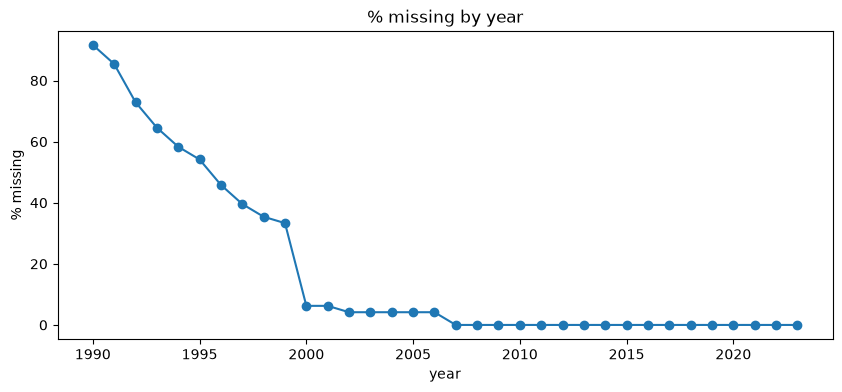

In [24]:
missing_by_year = df_ssa.groupby("year")["access_pct"].apply(lambda x: x.isna().mean() * 100)
missing_by_year.plot(kind="line", marker="o", figsize=(10,4), title="% missing by year")
plt.ylabel("% missing")
plt.show()

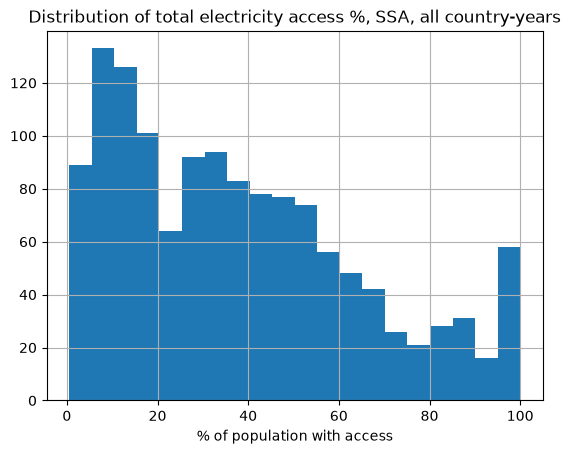

In [25]:
import matplotlib.pyplot as plt

df_ssa["access_pct"].dropna().hist(bins=20)
plt.title("Distribution of total electricity access %, SSA, all country-years")
plt.xlabel("% of population with access")
plt.show()

In [26]:
df_ssa["urban_rural_gap"] = df_ssa["access_urban_pct"] - df_ssa["access_rural_pct"]

df_ssa["urban_rural_gap"].describe()

count    1154.000000
mean       43.591247
std        20.503955
min        -8.200000
25%        31.325000
50%        44.800000
75%        57.800000
max        88.900000
Name: urban_rural_gap, dtype: float64

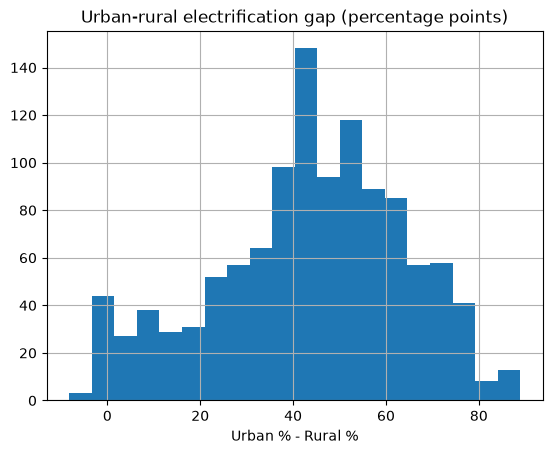

In [27]:
df_ssa["urban_rural_gap"].dropna().hist(bins=20)
plt.title("Urban-rural electrification gap (percentage points)")
plt.xlabel("Urban % - Rural %")
plt.show()

In [28]:
df_ssa_clean = df_ssa[df_ssa["year"] >= 2007]
df_ssa_clean.shape
df_ssa_clean[["access_pct","access_urban_pct","access_rural_pct"]].isna().sum()

access_pct           0
access_urban_pct     0
access_rural_pct    77
dtype: int64

1. Distribution of total electricity access %

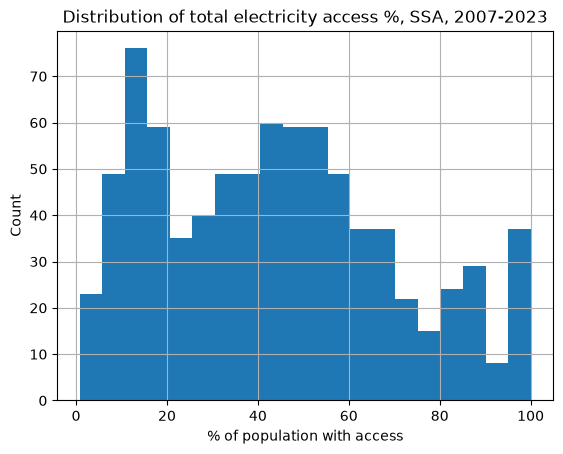

In [29]:
df_ssa_clean["access_pct"].dropna().hist(bins=20)
plt.title("Distribution of total electricity access %, SSA, 2007-2023")
plt.xlabel("% of population with access")
plt.ylabel("Count")
plt.show()

2. Urban vs rural side by side

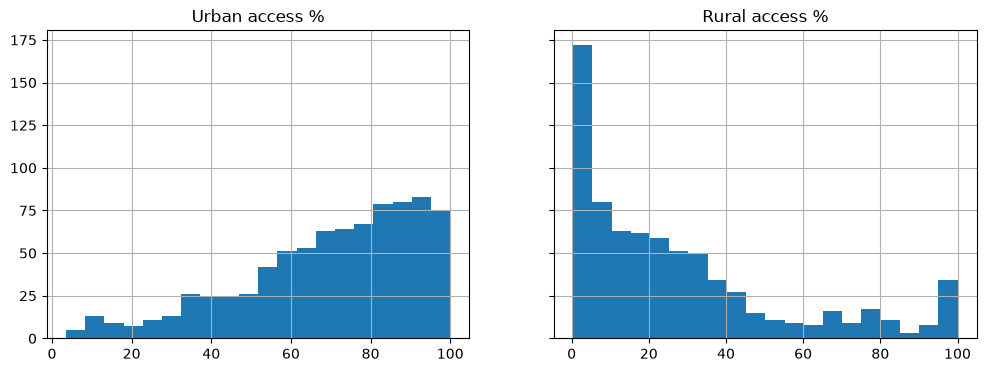

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
df_ssa_clean["access_urban_pct"].hist(bins=20, ax=axes[0])
axes[0].set_title("Urban access %")
df_ssa_clean["access_rural_pct"].hist(bins=20, ax=axes[1])
axes[1].set_title("Rural access %")
plt.show()

Urban access %: heavily skewed to the right. Most country-years cluster in the 75–100% range, tallest bar near 90-100%. Meaning: most African cities, most years, already have close to full electrification.

Rural access %: almost a mirror image — heavily skewed to the left. The tallest bar is right at 0-10%, and it thins out steadily as you move right, with a small bump near 90-100% (a handful of countries that have basically solved rural electrification too).

What this tells you, in plain words: across Sub-Saharan Africa, "having electricity" is basically a solved problem if you live in a city — but a coin-flip-or-worse problem if you live in the countryside. That's your urban-rural gap, visually proven. This is exactly the kind of finding that justifies why your topic matters.


3. The urban-rural gap — your core variable

In [31]:
df_ssa_clean["urban_rural_gap"] = df_ssa_clean["access_urban_pct"] - df_ssa_clean["access_rural_pct"]

df_ssa_clean["urban_rural_gap"].describe()

count    739.000000
mean      43.583627
std       21.065920
min       -8.200000
25%       29.550000
50%       46.200000
75%       57.650000
max       88.900000
Name: urban_rural_gap, dtype: float64

In [38]:
df_ssa_clean[df_ssa_clean["urban_rural_gap"] < 0][["Country Name", "year", "access_urban_pct", "access_rural_pct", "urban_rural_gap"]]

,Country Name,year,access_urban_pct,access_rural_pct,urban_rural_gap
7056,Mauritius,2016,99.6,99.8,-0.2
7373,Sao Tome and Principe,2017,73.5,76.2,-2.7
7586,Mauritius,2018,99.5,100.0,-0.5
8116,Mauritius,2020,99.4,99.5,-0.1
8212,South Africa,2020,87.3,95.5,-8.2
8262,Cabo Verde,2021,94.9,96.9,-2.0
8381,Mauritius,2021,99.3,99.8,-0.5
8477,South Africa,2021,87.4,93.4,-6.0
8527,Cabo Verde,2022,95.3,97.4,-2.1
8646,Mauritius,2022,99.0,100.0,-1.0


In [39]:
df_ssa_clean.sort_values("urban_rural_gap", ascending=False).head(5)[["Country Name", "year", "access_urban_pct", "access_rural_pct", "urban_rural_gap"]]

,Country Name,year,access_urban_pct,access_rural_pct,urban_rural_gap
8302,Equatorial Guinea,2021,90.3,1.4,88.9
8037,Equatorial Guinea,2020,90.5,1.8,88.7
7772,Equatorial Guinea,2019,90.8,2.4,88.4
8567,Equatorial Guinea,2022,89.8,1.4,88.4
7507,Equatorial Guinea,2018,91.0,2.9,88.1


### The negative gap countries (rural ≥ urban):
Notice it's not random noise — it's a specific, small group: Mauritius, South Africa, Cabo Verde, São Tomé and Príncipe. These have something in common: they're all relatively wealthier, smaller, or more developed African nations that have largely already solved electrification almost everywhere. When both urban and rural are near 95-100%, tiny survey differences (rounding, sampling year-to-year) can easily flip the sign slightly negative — it's less "rural beats urban" and more "both are basically fully electrified, so the gap is just noise around zero." South Africa's -6 to -8 point gaps are a bit bigger and could reflect real policy success in rural electrification programs there specifically — worth a one-line mention, not a deep dive.

The extreme gap country — Equatorial Guinea:
This one's a much sharper story. 90% urban vs. just 1-2% rural, repeated across multiple years (2018-2022). This is a striking real-world case: a country with real oil wealth that electrified its cities but essentially left rural areas behind almost entirely. This is a genuinely powerful example for your write-up — it's the most extreme version of exactly the pattern your whole project is about.







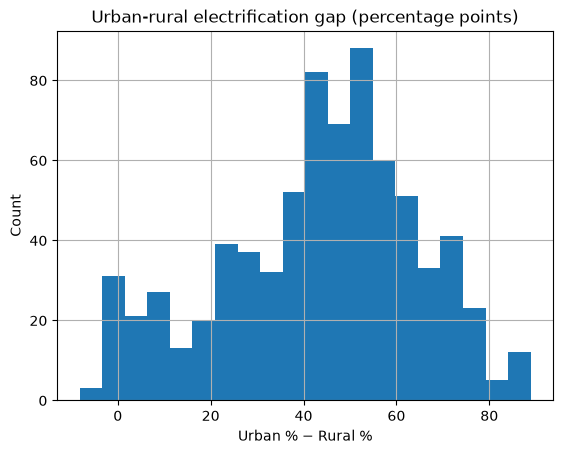

In [37]:
df_ssa_clean["urban_rural_gap"].dropna().hist(bins=20)
plt.title("Urban-rural electrification gap (percentage points)")
plt.xlabel("Urban % − Rural %")
plt.ylabel("Count")
plt.show()

In [33]:
df_ssa_clean[["Country Name", "year", "access_urban_pct", "access_rural_pct"]].head(10)

,Country Name,year,access_urban_pct,access_rural_pct
4509,Angola,2007,66.1,NaN
4521,Burundi,2007,51.8,NaN
4523,Benin,2007,53.8,9.7
4524,Burkina Faso,2007,48.2,1.2
4538,Botswana,2007,56.9,21.3
4539,Central African Republic,2007,19.6,1.4
4546,Cote d'Ivoire,2007,85.8,29.3
4547,Cameroon,2007,90.4,6.4
4548,"Congo, Dem. Rep.",2007,36.6,1.8
4549,"Congo, Rep.",2007,52.8,8.2


In [35]:
df_urban.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,NaN
1,Africa Eastern and Southern,AFE,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,70.947036,71.816938,72.955844,74.377118,75.841997,76.277014,80.649559,80.049274,NaN,NaN
2,Afghanistan,AFG,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,99.500000,98.800000,99.500000,99.500000,99.500000,95.900000,96.000000,97.000000,NaN,NaN
3,Africa Western and Central,AFW,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,82.849414,80.307983,82.678439,83.243717,86.686039,86.779377,84.804044,85.893843,NaN,NaN
4,Angola,AGO,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,69.400000,65.300000,72.200000,73.600000,75.000000,76.200000,77.900000,78.000000,NaN,NaN


In [36]:
df_rural.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,NaN
1,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,25.375037,26.941984,28.983183,30.909991,32.709837,33.998179,35.240236,36.080572,NaN,NaN
2,Afghanistan,AFG,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,97.100000,91.600000,97.100000,97.100000,97.100000,81.700000,81.400000,84.600000,NaN,NaN
3,Africa Western and Central,AFW,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,22.961144,28.021258,26.257143,24.689716,25.811787,25.188268,28.957420,34.953462,NaN,NaN
4,Angola,AGO,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7.300000,NaN,NaN,NaN,NaN,NaN,1.300000,NaN,NaN


In [40]:
df_ssa_clean[df_ssa_clean["Country Name"] == "Kenya"].sort_values("year")[["year", "access_urban_pct", "access_rural_pct", "urban_rural_gap"]]

,year,access_urban_pct,access_rural_pct,urban_rural_gap
4625,2007,62.0,18.6,43.4
4890,2008,63.8,20.4,43.4
5155,2009,65.6,10.1,55.5
5420,2010,58.2,7.2,51.0
5685,2011,69.3,25.7,43.6
5950,2012,71.1,27.5,43.6
6215,2013,73.0,29.3,43.7
6480,2014,68.4,25.1,43.3
6745,2015,78.1,29.0,49.1
7010,2016,84.3,42.1,42.2


Sub-Saharan Africa shows a large urban-rural electrification gap (mean ~44 percentage points, 2007-2023). Urban access is heavily skewed toward 75-100%, while rural access is skewed toward 0-25%. Equatorial Guinea shows the most extreme gap (up to 89 points), while a few wealthier/smaller nations like Mauritius show almost no gap at all. Kenya's gap has been shrinking since ~2015, likely reflecting the mini-grid/off-grid solar expansion documented in [reference], which matches the timing seen in the data.

In [41]:
df_ssa_clean.to_csv("ssa_electrification_clean_2007_2023.csv", index=False)


In [42]:
import os
print(os.getcwd())

c:\Users\user\Desktop\Analysis101
